Унікальні поліси в freq: 678013
Унікальні поліси в sev: 24950
Після мерджу кількість полісі з клеймом: 24944
Відрізки сформованих груп щільності:
             min    max  count    mean
DensityBin                            
Q1             1     42  86250    23.7
Q2            43     92  83723    64.3
Q3            93    188  84619   134.5
Q4           189    393  85625   275.4
Q5           394    817  83767   574.9
Q6           818   1658  84689  1210.9
Q7          1662   3859  85320  2847.2
Q8          3862  27000  84020  9274.6


/tmp/ipykernel_11952/836867775.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(merged.groupby('DensityBin')['Density'].agg(['min', 'max', 'count', 'mean']).round(1))
/tmp/ipykernel_11952/836867775.py:39: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = merged.pivot_table(


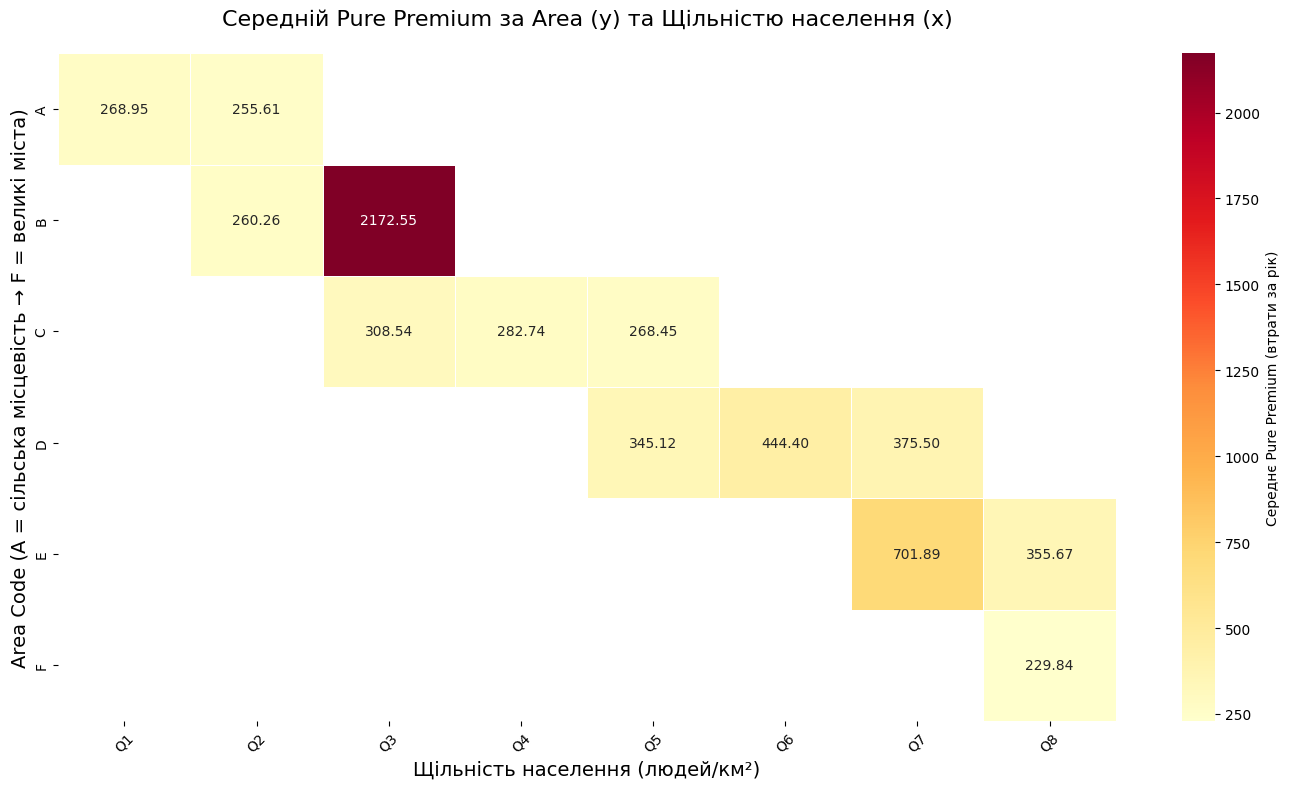

ДЕ найбільші втрати
Великі міста/густий трафік (велика щільність + Area F): 229.84 € за unit exposure(рік)
Сільська місцевість / швидкістні шосе (низька щільність + Area A/B): 364.63 €  за unit exposure(рік)
→ Компанія втрачає БІЛЬШЕ грошей на швидкістних шосе в сільських місцевостях

Average PurePremium by Area Code:
Area
A    266.68
B    499.56
C    290.53
D    403.43
E    535.13
F    229.84
Name: PurePremium, dtype: float64


/tmp/ipykernel_11952/836867775.py:89: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq_pivot = merged.pivot_table(values='ClaimNb', index='Area', columns='DensityBin', aggfunc='mean') / merged.pivot_table(values='Exposure', index='Area', columns='DensityBin', aggfunc='mean')
/tmp/ipykernel_11952/836867775.py:89: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq_pivot = merged.pivot_table(values='ClaimNb', index='Area', columns='DensityBin', aggfunc='mean') / merged.pivot_table(values='Exposure', index='Area', columns='DensityBin', aggfunc='mean')


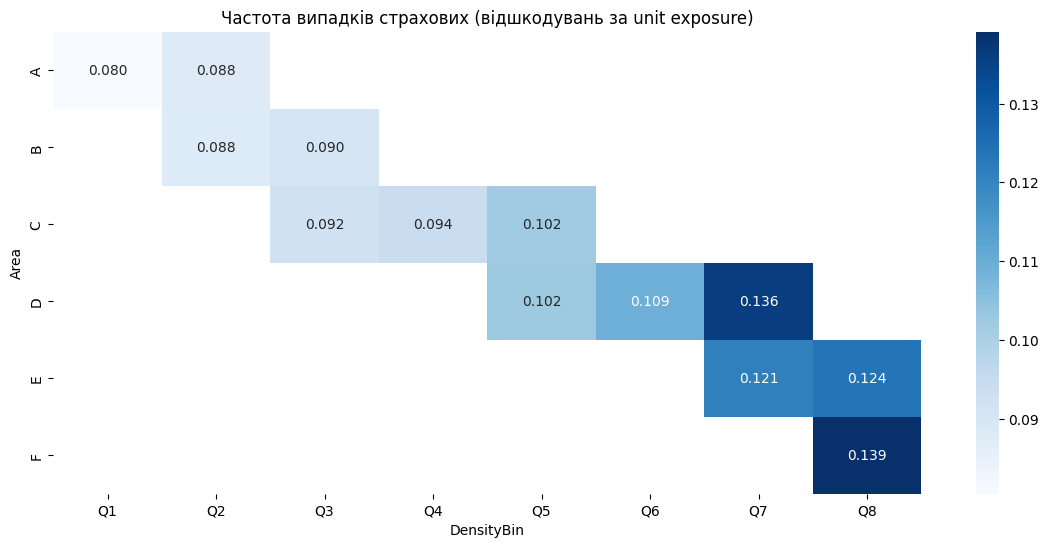

/tmp/ipykernel_11952/836867775.py:98: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  sev_pivot = merged[merged['TotalClaimAmount'] > 0].pivot_table(


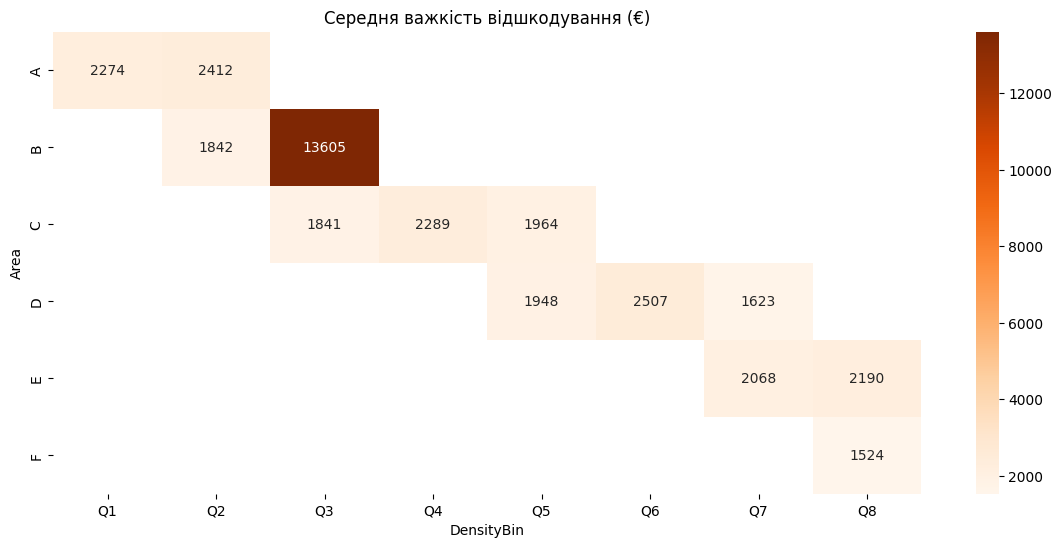

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

freq = pd.read_csv('freMTPL2freq.csv')
sev = pd.read_csv('freMTPL2sev.csv')

print(f"Унікальні поліси в freq: {freq['IDpol'].nunique()}")
print(f"Унікальні поліси в sev: {sev['IDpol'].nunique()}")


sev_agg = sev.groupby('IDpol')['ClaimAmount'].sum().reset_index()
sev_agg = sev_agg.rename(columns={'ClaimAmount': 'TotalClaimAmount'})


merged = freq.merge(sev_agg, on='IDpol', how='left')
merged['TotalClaimAmount'] = merged['TotalClaimAmount'].fillna(0)

print(f"Після мерджу кількість полісі з клеймом: {(merged['TotalClaimAmount'] > 0).sum()}")

# втрати за юніт часу(тут рік)
merged['PurePremium'] = merged['TotalClaimAmount'] / merged['Exposure']

merged['DensityBin'] = pd.qcut(
    merged['Density'],
    q=8,                    # 8 однакових груп (+- 12.5% всіх полісів)
    labels=[f'Q{i+1}' for i in range(8)],
    duplicates='drop'
)

print("Відрізки сформованих груп щільності:")
print(merged.groupby('DensityBin')['Density'].agg(['min', 'max', 'count', 'mean']).round(1))

# 5. BUILD THE PIVOT TABLE FOR HEATMAP
# Rows = Area code (y-axis)
# Columns = Density bins (x-axis)
# Values = average PurePremium (how much money the company loses per unit exposure)
heatmap_data = merged.pivot_table(
    values='PurePremium',
    index='Area',
    columns='DensityBin',
    aggfunc='mean'
)

# Sort Area from rural (A) to urban (F)
heatmap_data = heatmap_data.reindex(['A', 'B', 'C', 'D', 'E', 'F'])

# хітмапа
plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Середнє Pure Premium (втрати за рік)'},
    linewidths=0.5
)
plt.title('Середній Pure Premium за Area (y) та Щільністю населення (x)', fontsize=16, pad=20)
plt.xlabel('Щільність населення (людей/км²)', fontsize=14)
plt.ylabel('Area Code (A = сільська місцевість → F = великі міста)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('PurePremium_Heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


print("ДЕ найбільші втрати")


major_cities = merged[(merged['Density'] > 10000) | (merged['Area'] == 'F')]['PurePremium'].mean()
rural_highways = merged[(merged['Density'] < 500) & (merged['Area'].isin(['A', 'B']))]['PurePremium'].mean()

print(f"Великі міста/густий трафік (велика щільність + Area F): {major_cities:.2f} € за unit exposure(рік)")
print(f"Сільська місцевість / швидкістні шосе (низька щільність + Area A/B): {rural_highways:.2f} €  за unit exposure(рік)")

if major_cities > rural_highways:
    print("→ Компанія втрачає БІЛЬШЕ грошей в густому трафіку великих міст")
else:
    print("→ Компанія втрачає БІЛЬШЕ грошей на швидкістних шосе в сільських місцевостях")


# середні втрати саме по Area
area_loss = merged.groupby('Area')['PurePremium'].mean().reindex(['A','B','C','D','E','F'])
print("\nAverage PurePremium by Area Code:")
print(area_loss.round(2))

# хітпама частоти випадків за unit exposure
freq_pivot = merged.pivot_table(values='ClaimNb', index='Area', columns='DensityBin', aggfunc='mean') / merged.pivot_table(values='Exposure', index='Area', columns='DensityBin', aggfunc='mean')
plt.figure(figsize=(14, 6))
sns.heatmap(freq_pivot.reindex(['A','B','C','D','E','F']), annot=True, fmt='.3f', cmap='Blues')
plt.title('Частота випадків страхових (відшкодувань за unit exposure)')
plt.savefig('ClaimFrequency_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


# хітмапа важкості випадків (наскільки дорогі клейми в середньому)
sev_pivot = merged[merged['TotalClaimAmount'] > 0].pivot_table(
    values='TotalClaimAmount',
    index='Area',
    columns='DensityBin',
    aggfunc=lambda x: x.sum() / (merged.loc[x.index, 'ClaimNb'].sum())  # середня сума відшкодування
)
plt.figure(figsize=(14, 6))
sns.heatmap(sev_pivot.reindex(['A','B','C','D','E','F']), annot=True, fmt='.0f', cmap='Oranges')
plt.title('Середня важкість відшкодування (€)')
plt.savefig('ClaimSeverity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
